In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
from scipy.stats import entropy
import matplotlib.pyplot as plt
from collections import deque

# Styling
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- Optimal Stopping Environment Ready. Using device: {device} ---")

class OptimalStoppingMDP:
    """
    An Asset Selling Problem.
    States: Price levels 0 to 10.
    Actions: 0 (Hold), 1 (Sell).
    """
    def __init__(self, max_price=10):
        self.max_price = max_price
        self.n = max_price + 1
        self.state = 5 # Start at mid-price
        self.action_space = [0, 1]

    def reset(self):
        self.state = 5
        return self._one_hot(self.state)

    def step(self, action):
        if action == 1: # SELL
            reward = float(self.state) # Get current price
            done = True
            return self._one_hot(self.state), reward, done
        
        # HOLD: Price moves randomly
        prob = random.random()
        if prob < 0.4: self.state = min(self.max_price, self.state + 1)
        elif prob < 0.8: self.state = max(0, self.state - 1)
        # 20% chance price stays the same
        
        # Holding cost to encourage optimal timing
        reward = -0.1 
        done = False
        return self._one_hot(self.state), reward, done

    def _one_hot(self, s):
        v = np.zeros(self.n, dtype=np.float32)
        v[s] = 1.0
        return v

--- Optimal Stopping Environment Ready. Using device: cuda ---


In [5]:
print("--- Calculating True Bellman Optimal Q-Values for Optimal Stopping ---")
n_states = 11; n_actions = 2; gamma = 0.99
Q_star_np = np.zeros((n_states, n_actions))
V_star_np = np.zeros(n_states)

# Value Iteration
for _ in range(1000):
    for s in range(n_states):
        # Action 1: SELL
        Q_star_np[s, 1] = float(s)
        
        # Action 0: HOLD
        v_stay = V_star_np[s]
        v_up = V_star_np[min(10, s + 1)]
        v_down = V_star_np[max(0, s - 1)]
        # Expected value under the 0.4 / 0.4 / 0.2 dynamics
        expected_v_next = 0.4 * v_up + 0.4 * v_down + 0.2 * v_stay
        Q_star_np[s, 0] = -0.1 + gamma * expected_v_next
        
        V_star_np[s] = np.max(Q_star_np[s])

Q_star_tensor = torch.FloatTensor(Q_star_np).to(device)

--- Calculating True Bellman Optimal Q-Values for Optimal Stopping ---


In [6]:
class TinyDQN(nn.Module):
    def __init__(self, state_dim=11, action_dim=2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(state_dim, 32), nn.ReLU(), nn.Linear(32, action_dim))
    def forward(self, x): return self.net(x)

class ToyGenerativeModel(nn.Module):
    def __init__(self, state_dim=11, action_dim=2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(state_dim + action_dim, 32), nn.ReLU(), nn.Linear(32, state_dim))
    def forward(self, s, a): return self.net(torch.cat([s, a], dim=1))
    def sample(self, s, a):
        logits = self.forward(s, a)
        probs = F.softmax(logits, dim=1)
        return F.one_hot(torch.multinomial(probs, 1).squeeze(), num_classes=11).float().cpu().numpy()

class RecursiveDataManager:
    def __init__(self, capacity=10000):
        self.real_buffer = deque(maxlen=capacity)
        self.mu_n_minus_1 = []; self.current_mu_n = []
    def push_real(self, t): self.real_buffer.append(t)
    
    def form_empirical_batch(self, gen_model, N, a, b, c):
        n_a, n_b = int(N * a), int(N * b)
        new_batch = []
        if n_a > 0 and len(self.real_buffer) >= n_a: new_batch.extend(random.sample(self.real_buffer, n_a))
        if n_b > 0 and len(self.real_buffer) > 0:
            seeds = random.choices(self.real_buffer, k=n_b)
            s_t = torch.FloatTensor(np.array([x[0] for x in seeds])).to(device)
            a_t = F.one_hot(torch.tensor([x[1] for x in seeds]), num_classes=2).float().to(device)
            ns_syn = gen_model.sample(s_t, a_t)
            for i in range(n_b): new_batch.append((seeds[i][0], seeds[i][1], seeds[i][2], ns_syn[i], seeds[i][4]))
        
        n_c = N - len(new_batch)
        if n_c > 0 and self.mu_n_minus_1: new_batch.extend(random.choices(self.mu_n_minus_1, k=n_c))
        while len(new_batch) < N: new_batch.append(random.choice(self.real_buffer))
        self.mu_n_minus_1 = self.current_mu_n; self.current_mu_n = new_batch
        return self.current_mu_n

    def sample_policy_mixture(self, batch_size, a_p, b_p, c_p, gen_model):
        n_a, n_b = int(batch_size * a_p), int(batch_size * b_p)
        batch = []
        if n_a > 0 and len(self.real_buffer) >= n_a: batch.extend(random.sample(self.real_buffer, n_a))
        if n_b > 0 and len(self.real_buffer) > 0:
            seeds = random.choices(self.real_buffer, k=n_b)
            s_t = torch.FloatTensor(np.array([x[0] for x in seeds])).to(device)
            a_t = F.one_hot(torch.tensor([x[1] for x in seeds]), num_classes=2).float().to(device)
            ns_syn = gen_model.sample(s_t, a_t)
            for i in range(n_b): batch.append((seeds[i][0], seeds[i][1], seeds[i][2], ns_syn[i], seeds[i][4]))
        
        n_c = batch_size - len(batch)
        if n_c > 0 and self.current_mu_n: batch.extend(random.choices(self.current_mu_n, k=n_c))
        while len(batch) < batch_size: batch.append(random.choice(self.real_buffer))
        return batch

--- Training Pure DQN Diagnostic on Optimal Stopping ---


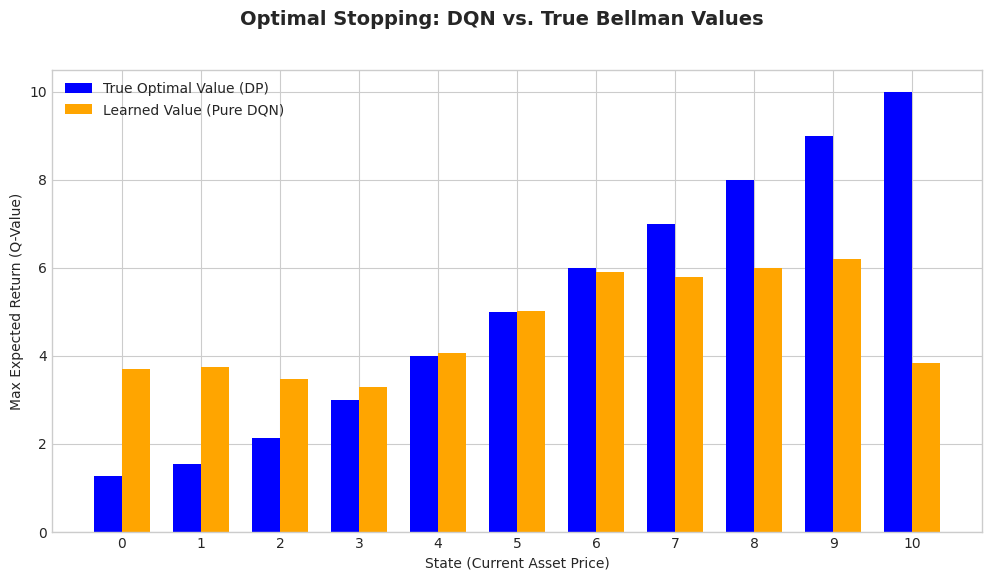

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
import matplotlib.pyplot as plt

# --- ISOLATED DIAGNOSTIC: PURE DQN ---
print("--- Training Pure DQN Diagnostic on Optimal Stopping ---")

env_diag = OptimalStoppingMDP()
agent_diag = TinyDQN(state_dim=11, action_dim=2).to(device)
target_agent_diag = TinyDQN(state_dim=11, action_dim=2).to(device)
target_agent_diag.load_state_dict(agent_diag.state_dict())

# Use LR=0.001 to prevent weight thrashing
optimizer_diag = optim.Adam(agent_diag.parameters(), lr=0.001) 
buffer_diag = []

epsilon = 1.0
epsilon_decay = 0.99
batch_size = 64
gamma = 0.99

for ep in range(1000):
    s = env_diag.reset()
    for step in range(50):
        if random.random() < epsilon: a = random.choice(env_diag.action_space)
        else:
            with torch.no_grad():
                a = agent_diag(torch.FloatTensor(s).to(device)).argmax().item()
        
        ns, r, done = env_diag.step(a)
        buffer_diag.append((s, a, r, ns, done))
        if len(buffer_diag) > 10000: buffer_diag.pop(0)
        s = ns
        
        if len(buffer_diag) >= batch_size:
            batch = random.sample(buffer_diag, batch_size)
            states = torch.FloatTensor(np.array([x[0] for x in batch])).to(device)
            actions = torch.tensor([x[1] for x in batch]).long().unsqueeze(1).to(device)
            rewards = torch.FloatTensor([x[2] for x in batch]).to(device)
            next_states = torch.FloatTensor(np.array([x[3] for x in batch])).to(device)
            dones = torch.FloatTensor([x[4] for x in batch]).to(device)
            
            q_vals = agent_diag(states).gather(1, actions).squeeze(1)
            next_q_vals = target_agent_diag(next_states).max(1)[0]
            expected_q = rewards + gamma * next_q_vals * (1 - dones)
            
            loss = F.mse_loss(q_vals, expected_q.detach())
            optimizer_diag.zero_grad(); loss.backward(); optimizer_diag.step()
        if done: break
            
    epsilon = max(0.01, epsilon * epsilon_decay)
    if ep % 10 == 0: target_agent_diag.load_state_dict(agent_diag.state_dict())

# Extract Learned Values
Q_dqn_np = np.zeros((11, 2))
with torch.no_grad():
    for s_idx in range(11):
        Q_dqn_np[s_idx] = agent_diag(torch.FloatTensor(env_diag._one_hot(s_idx)).to(device)).cpu().numpy()
V_dqn_np = np.max(Q_dqn_np, axis=1)

# Plotting
states_x = np.arange(11) 
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Optimal Stopping: DQN vs. True Bellman Values", fontsize=14, fontweight='bold')

ax.bar(states_x - width/2, V_star_np, width, label='True Optimal Value (DP)', color='blue')
ax.bar(states_x + width/2, V_dqn_np, width, label='Learned Value (Pure DQN)', color='orange')
ax.set_xlabel("State (Current Asset Price)"); ax.set_ylabel("Max Expected Return (Q-Value)")
ax.set_xticks(states_x)
ax.legend()
plt.show()

In [8]:
def train_generative_model(model, optimizer, batch):
    if not batch: return
    s = torch.FloatTensor(np.array([x[0] for x in batch])).to(device)
    a = F.one_hot(torch.tensor([x[1] for x in batch]), num_classes=2).float().to(device)
    ns_target = torch.tensor([np.argmax(x[3]) for x in batch]).to(device)
    optimizer.zero_grad(); F.cross_entropy(model(s, a), ns_target).backward(); optimizer.step()

def train_policy_step(agent, target_agent, optimizer, batch):
    states = torch.FloatTensor(np.array([x[0] for x in batch])).to(device)
    actions = torch.tensor([x[1] for x in batch]).long().to(device).unsqueeze(1)
    rewards = torch.FloatTensor([x[2] for x in batch]).to(device)
    next_states = torch.FloatTensor(np.array([x[3] for x in batch])).to(device)
    dones = torch.FloatTensor([x[4] for x in batch]).to(device)
    q_vals = agent(states).gather(1, actions).squeeze(1)
    next_q = target_agent(next_states).max(1)[0]
    optimizer.zero_grad(); F.mse_loss(q_vals, (rewards + 0.99 * next_q * (1-dones)).detach()).backward(); optimizer.step()

In [9]:
def run_toy_experiment(label, episodes=1000, a=1.0, b=0.0, c=0.0, a_p=1.0, b_p=0.0, c_p=0.0):
    env = OptimalStoppingMDP()
    data_manager = RecursiveDataManager()
    agent = TinyDQN().to(device); target_agent = TinyDQN().to(device)
    target_agent.load_state_dict(agent.state_dict())
    optimizer = optim.Adam(agent.parameters(), lr=0.001)
    gen_model = ToyGenerativeModel().to(device); gen_optimizer = optim.Adam(gen_model.parameters(), lr=0.01)
    
    metrics = {k: [] for k in ['returns', 'gen_entropy', 'gen_tvd', 'mse_q', 'buffer_coverage']}
    holdout_states = torch.eye(11).float().to(device)
    epsilon = 1.0
    
    for ep in range(episodes):
        state = env.reset()
        for step in range(50):
            if random.random() < epsilon: action = random.choice(env.action_space)
            else: action = agent(torch.FloatTensor(state).to(device)).argmax().item()
            
            ns, r, done = env.step(action)
            data_manager.push_real((state, action, r, ns, done))
            state = ns
            if len(data_manager.real_buffer) > 64 and step % 5 == 0:
                mu_batch = data_manager.form_empirical_batch(gen_model, 256, a, b, c)
                train_generative_model(gen_model, gen_optimizer, mu_batch)
                for _ in range(5):
                    p_batch = data_manager.sample_policy_mixture(64, a_p, b_p, c_p, gen_model)
                    train_policy_step(agent, target_agent, optimizer, p_batch)
            if done: break
        
        epsilon = max(0.01, epsilon * 0.99)
        if ep % 10 == 0: target_agent.load_state_dict(agent.state_dict())
        
        # Evaluation
        if len(data_manager.real_buffer) > 64:
            seeds = random.choices(data_manager.real_buffer, k=256)
            s_t = torch.FloatTensor(np.array([x[0] for x in seeds])).to(device)
            a_t = F.one_hot(torch.tensor([x[1] for x in seeds]), num_classes=2).float().to(device)
            syn_ns_idx = np.array([np.argmax(x) for x in gen_model.sample(s_t, a_t)])
            counts = np.bincount(syn_ns_idx, minlength=11)
            metrics['gen_entropy'].append(entropy(counts/(counts.sum()+1e-9)+1e-9))
            
            real_ns_idx = np.array([np.argmax(x[3]) for x in data_manager.real_buffer])
            real_probs = np.bincount(real_ns_idx, minlength=11)/(len(real_ns_idx)+1e-9)
            metrics['gen_tvd'].append(0.5 * np.sum(np.abs(counts/counts.sum() - real_probs)))
            
            unique_s = len(set([np.argmax(x[0]) for x in data_manager.current_mu_n])) if data_manager.current_mu_n else 0
            metrics['buffer_coverage'].append(unique_s / 11.0)
            
            with torch.no_grad():
                q_vals = agent(holdout_states)
                metrics['mse_q'].append(F.mse_loss(q_vals, Q_star_tensor).item())
                
                # Test Episode
                ts = env.reset(); tr = 0
                for _ in range(50):
                    ba = agent(torch.FloatTensor(ts).to(device)).argmax().item()
                    ts, r, d = env.step(ba); tr += r
                    if d: break
                metrics['returns'].append(tr)
        else:
            for k in metrics: metrics[k].append(0.0)
            
    return metrics

In [20]:
m_perfect = run_toy_experiment("1. Baseline (Perfect Learning)", a=1.0, b=0.0, c=0.0, a_p=1.0, b_p=0.0, c_p=0.0)
m_diffusion_mixed = run_toy_experiment("2. Diffusion Mixed", a=0.5, b=0.25, c=0.25, a_p=1.0, b_p=0.0, c_p=0.0)
m_perfect_model_mixed_policy = run_toy_experiment("3. Baseline (Stable Learning)", a=1.0, b=0.0, c=0.0, a_p=0.5, b_p=0.5, c_p=0.0)
m_model_collapse_mixed_policy = run_toy_experiment("4. Generative Model Collapse mixed policy", a=0.0, b=1.0, c=0.0, a_p=0.5, b_p=0.5, c_p=0.0)
m_model_collapse_synthetic_policy = run_toy_experiment("5.Model collapse and Only Synthetic Data for Policy", a=0.0, b=0.5, c=0.5, a_p=0.0, b_p=1.0, c_p=0.0)
m_control_collapse_two = run_toy_experiment("6. Control Collapse two", a=0.0, b=0.0, c=1.0, a_p=0.0, b_p=0.0, c_p=1.0)
m_synthetic_synthetic = run_toy_experiment("7. Only Synthetic Data for Both", a=0.0, b=1.0, c=0.0, a_p=0.0, b_p=1.0, c_p=0.0)

m_model_collapse_but_not_control = run_toy_experiment("8. Model Collapse but Not Control", a=0.0, b=1.0, c=0.0, a_p=0.5, b_p=0.5, c_p=0.0)
m_control_collapse_but_not_model = run_toy_experiment("9. Control Collapse but Not Model", a=0.5, b=0.5, c=0.0, a_p=0.0, b_p=0.5, c_p=0.5)

PART 1: THE CORE EXTREMES (3 EXPERIMENTS)


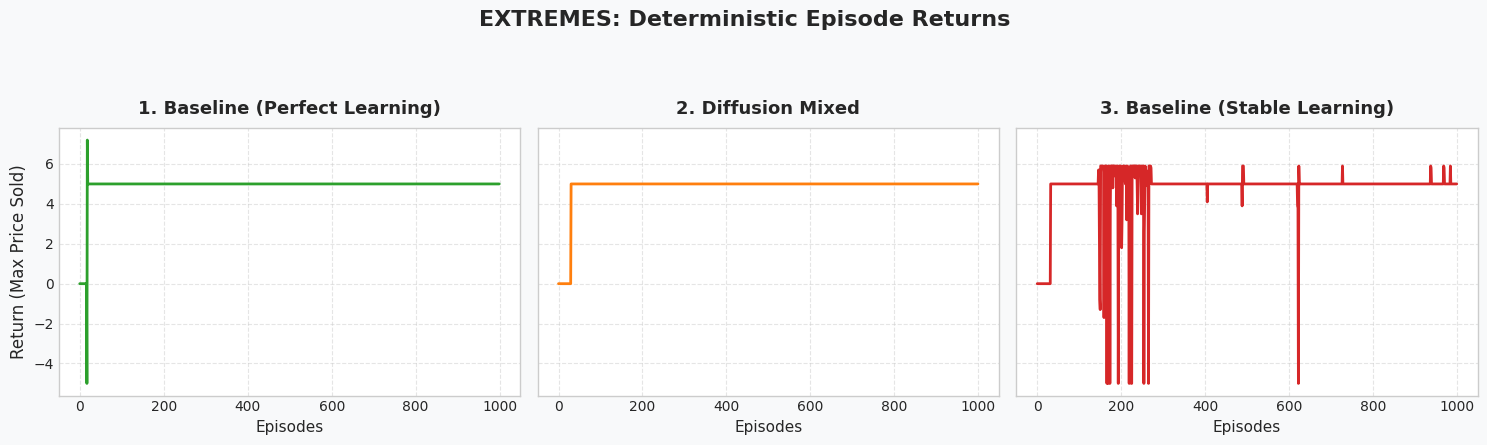

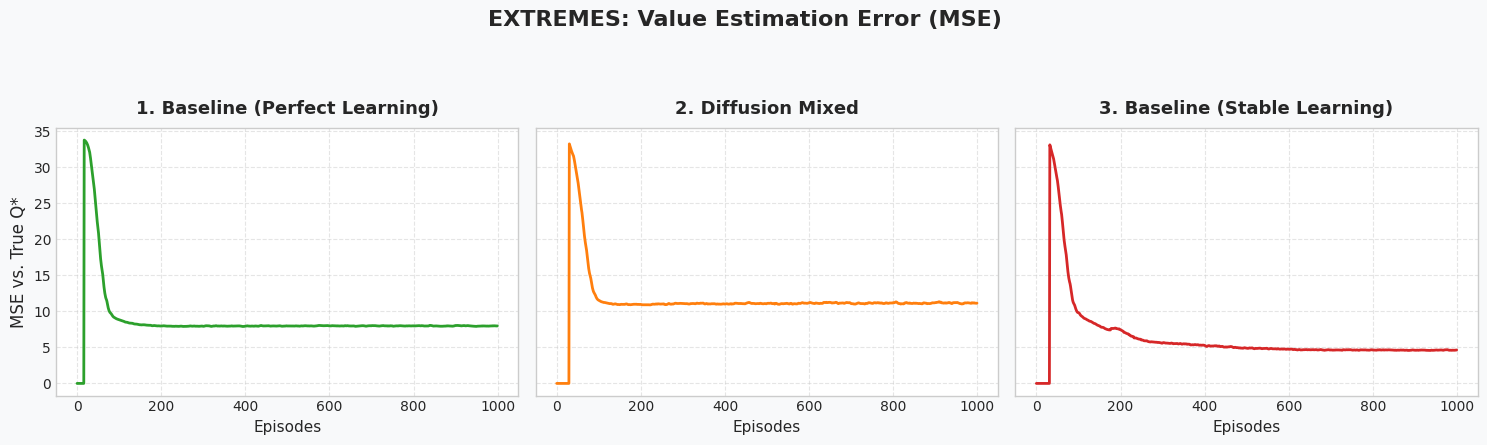

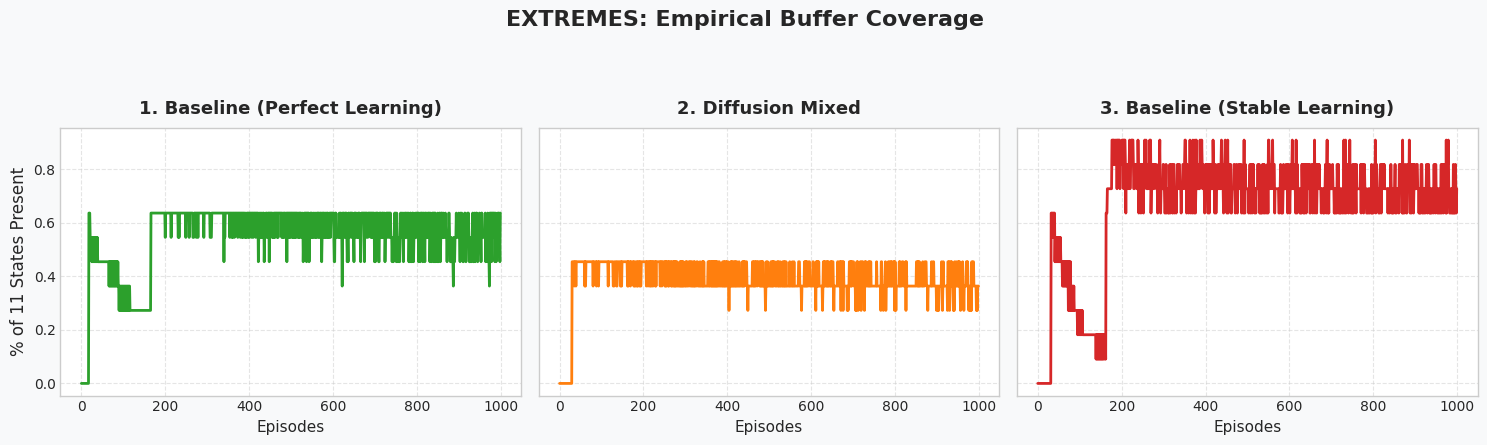

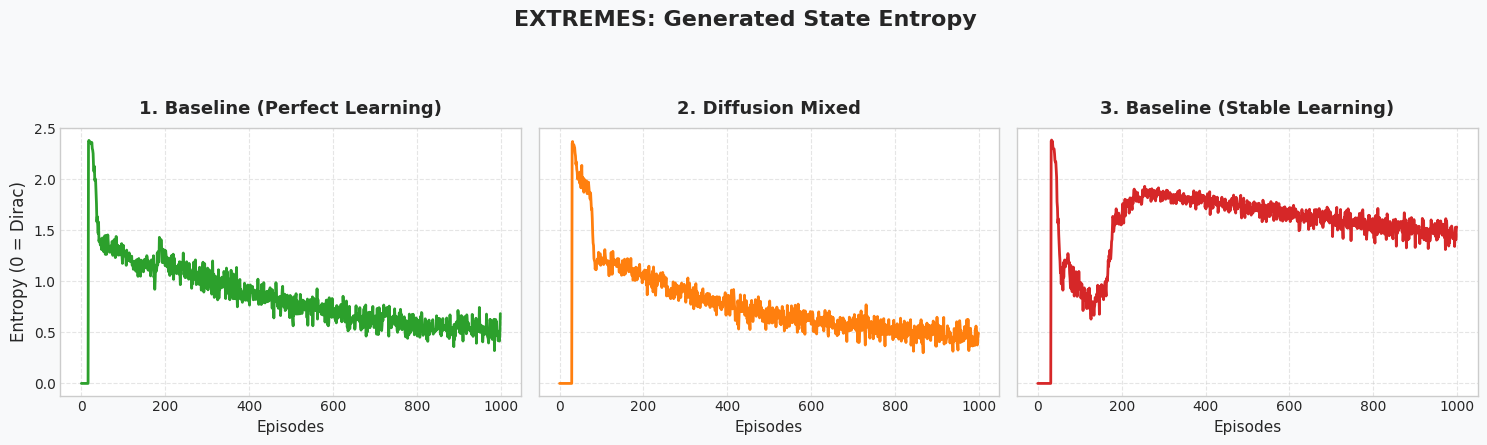

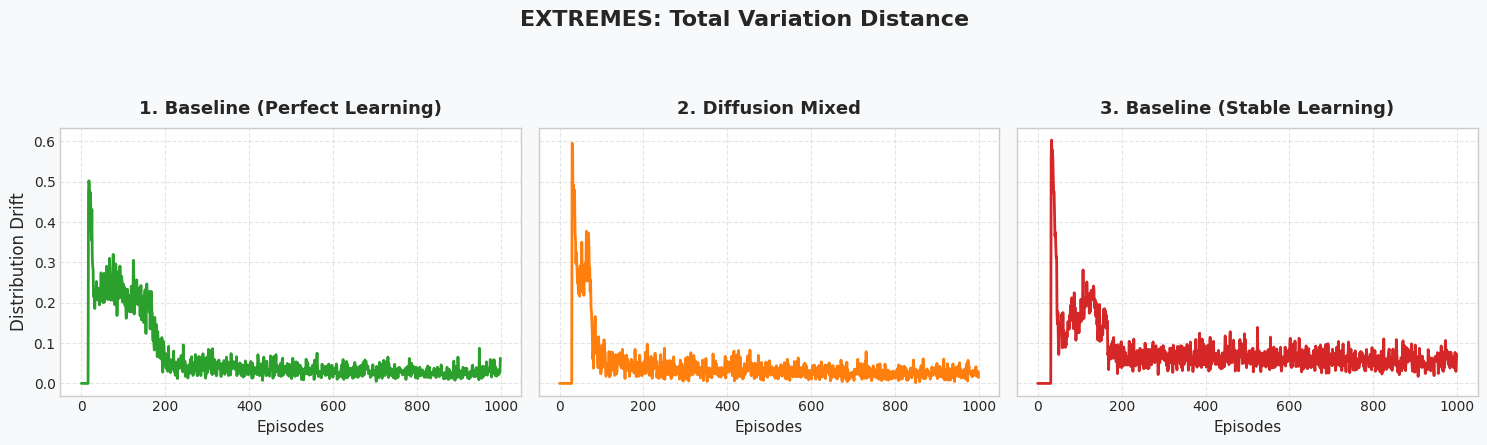

PART 2: THE MIXTURES & ABLATIONS (4 EXPERIMENTS)


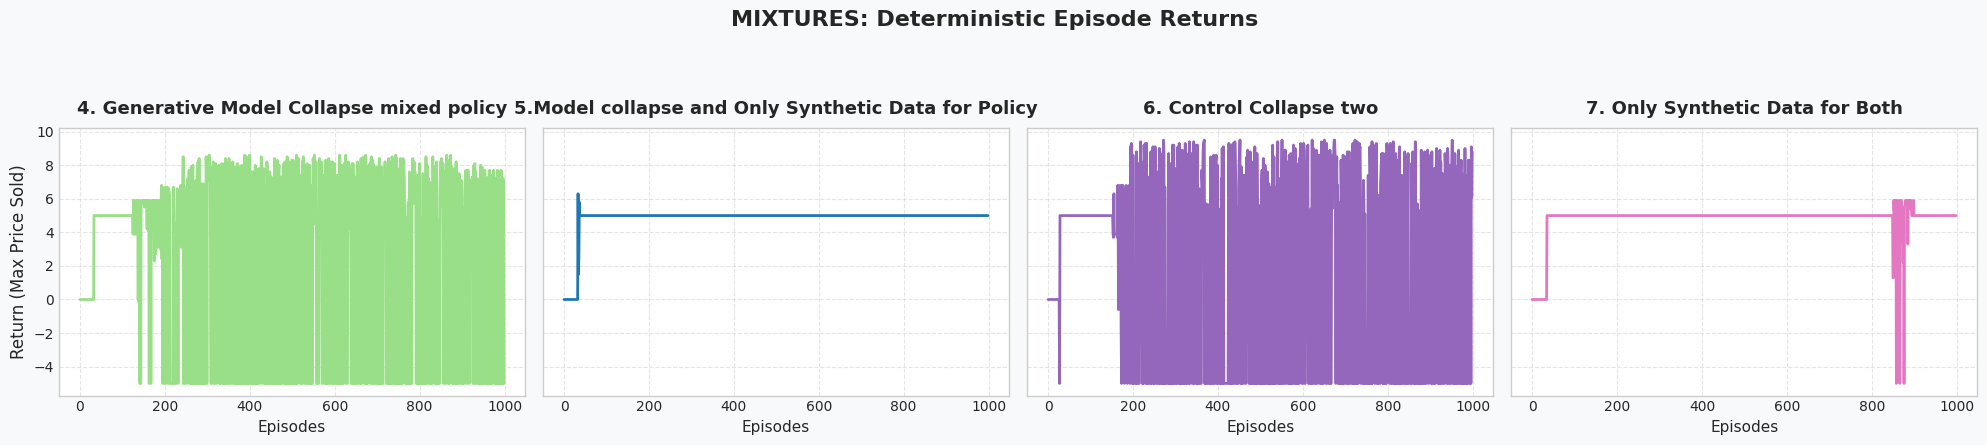

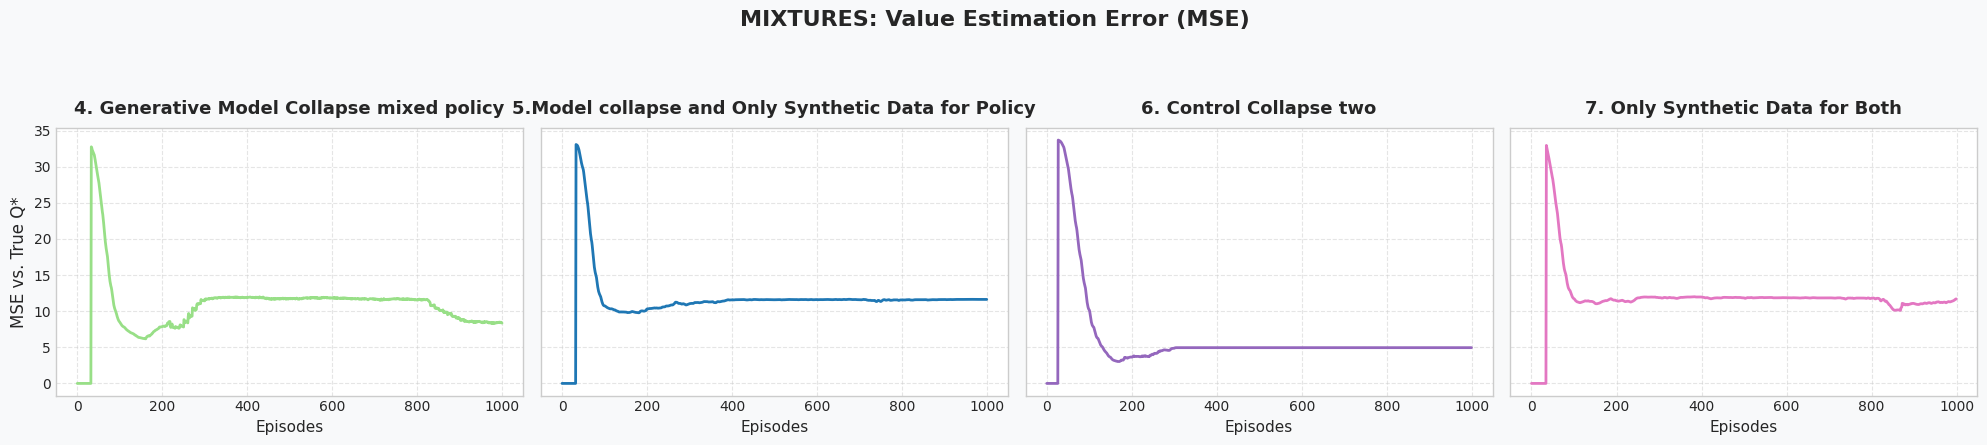

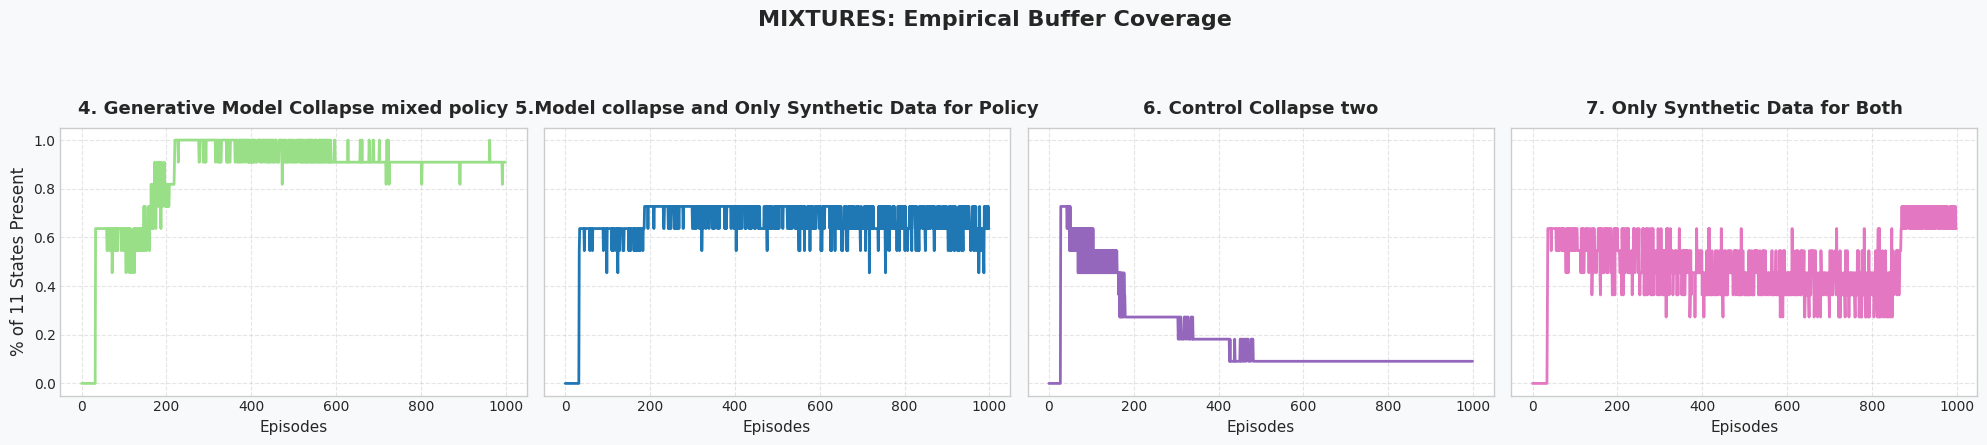

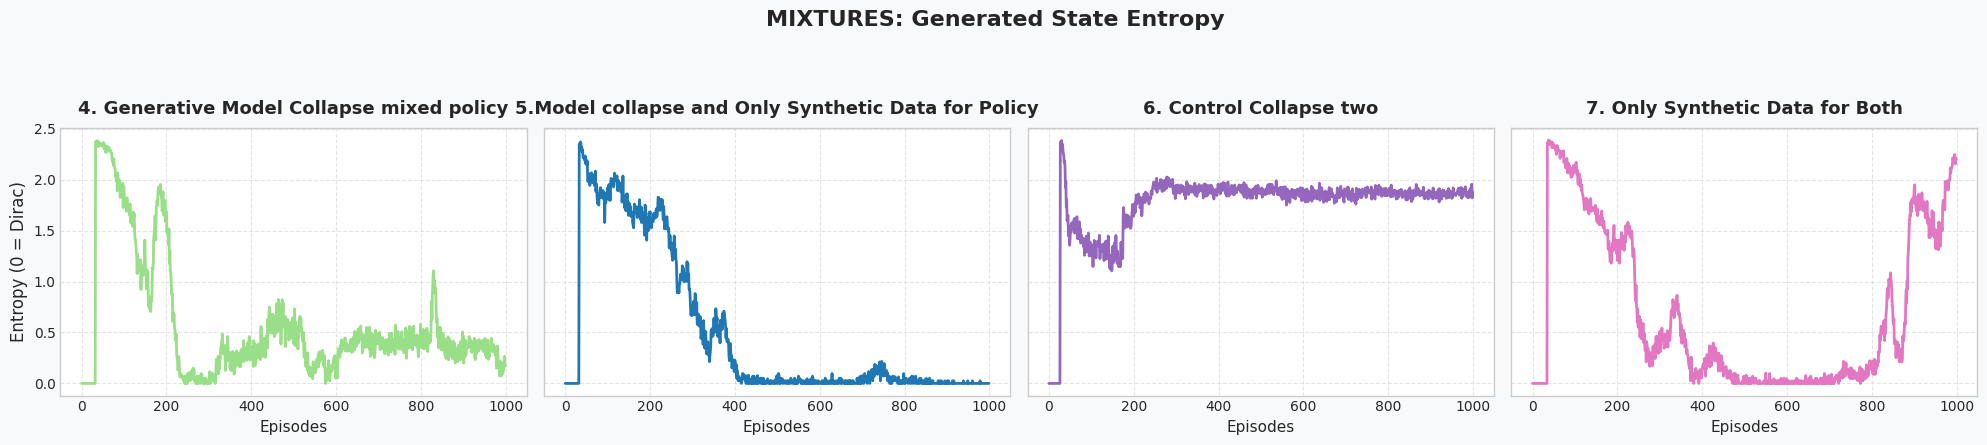

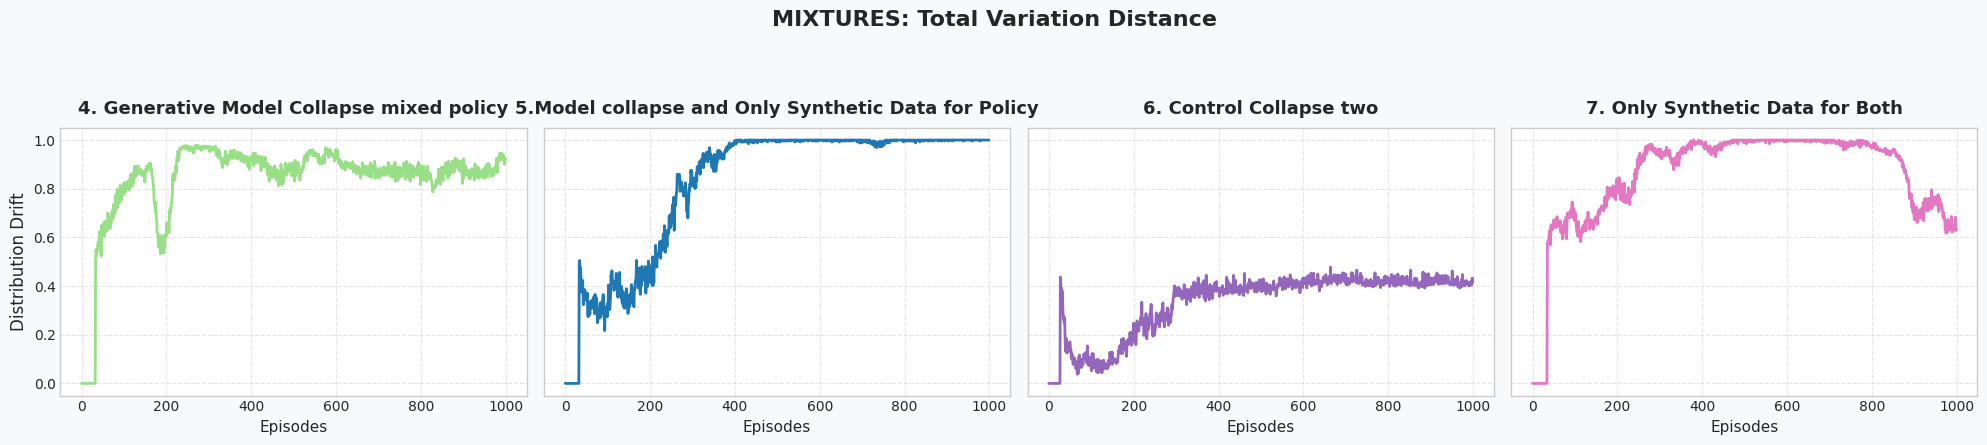

PART 3: THE ABLATIONS (2 EXPERIMENTS)


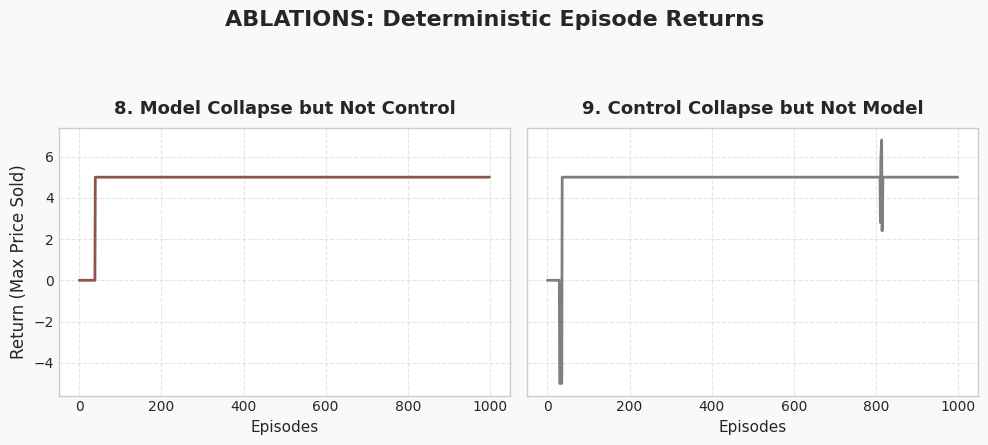

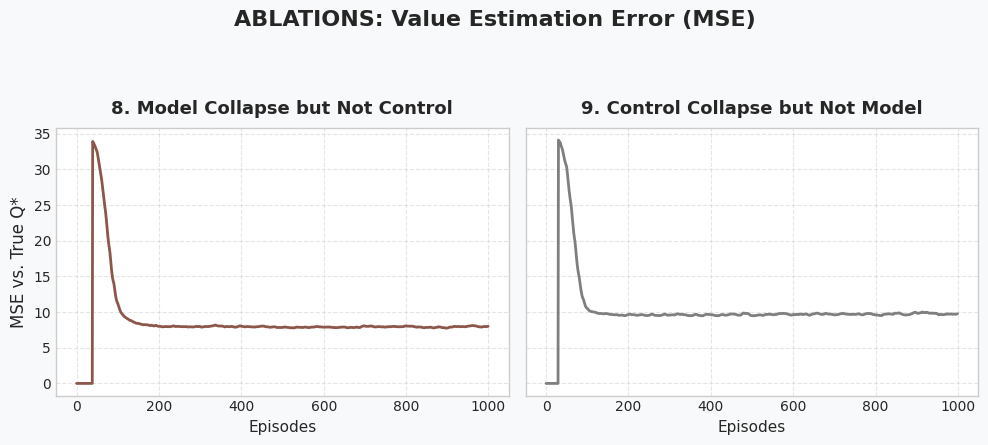

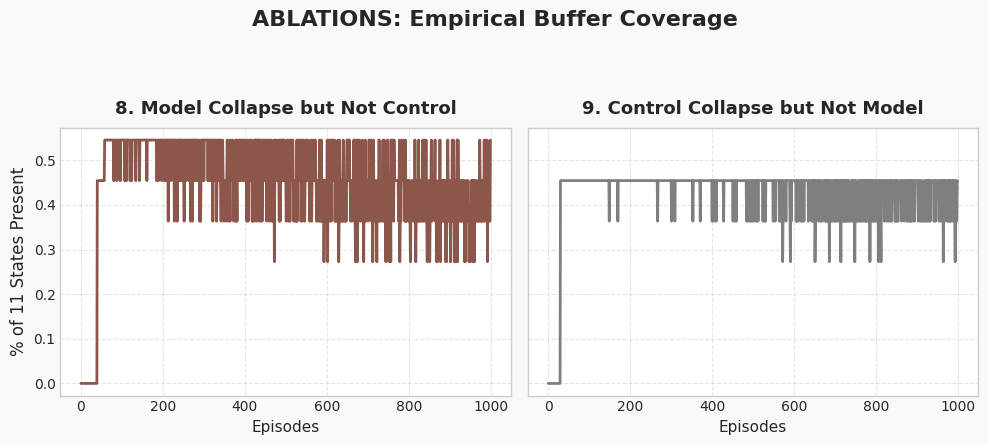

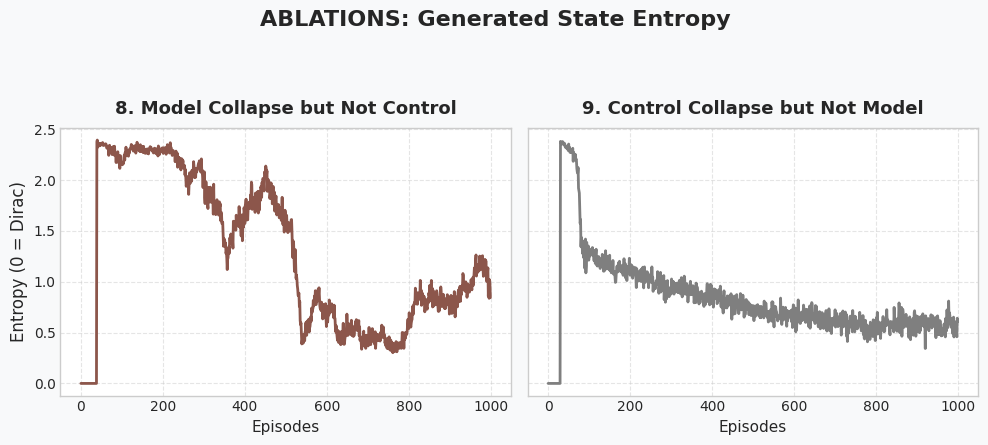

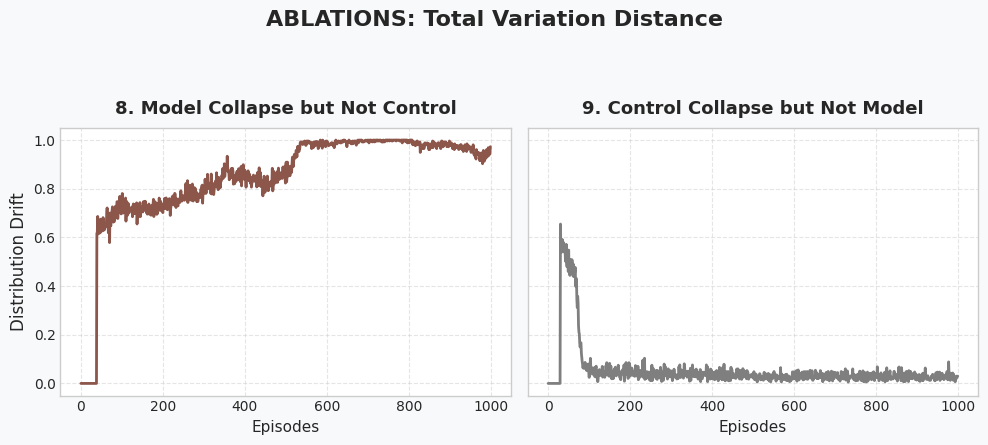

In [21]:
import matplotlib.pyplot as plt

metrics_to_plot = [
    ('returns', "Deterministic Episode Returns", "Return (Max Price Sold)"),
    ('mse_q', "Value Estimation Error (MSE)", "MSE vs. True Q*"),
    ('buffer_coverage', "Empirical Buffer Coverage", "% of 11 States Present"),
    ('gen_entropy', "Generated State Entropy", "Entropy (0 = Dirac)"),
    ('gen_tvd', "Total Variation Distance", "Distribution Drift")
]

# Define Groups and Colors
group_1 = [
    ('1. Baseline (Perfect Learning)', m_perfect, '#2ca02c'),          # Green
    ('2. Diffusion Mixed', m_diffusion_mixed, '#ff7f0e'),  # Orange
    ('3. Baseline (Stable Learning)', m_perfect_model_mixed_policy, '#d62728'),  # Red
]

group_2 = [
    ('4. Generative Model Collapse mixed policy', m_model_collapse_mixed_policy, '#98df87'),  # Light Green
    ('5.Model collapse and Only Synthetic Data for Policy', m_model_collapse_synthetic_policy, '#1f77b4'),# Blue
    ('6. Control Collapse two', m_control_collapse_two, '#9467bd'),     # Purple
    ('7. Only Synthetic Data for Both', m_synthetic_synthetic, '#e377c2'),       # Pink
]

group_3 = [
    ('8. Model Collapse but Not Control', m_model_collapse_but_not_control, '#8c564b'),  # Brown
    ('9. Control Collapse but Not Model', m_control_collapse_but_not_model, '#7f7f7f'),  # Gray
]

def plot_group(group_data, title_prefix):
    for metric_key, title, ylabel in metrics_to_plot:
        # Create subplots dynamically based on the number of experiments in the group
        n_plots = len(group_data)
        fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4), facecolor='#f8f9fa', sharey=True)
        fig.suptitle(f"{title_prefix}: {title}", fontsize=16, fontweight='bold', y=1.1)
        
        for i, (name, data, color) in enumerate(group_data):
            ax = axes[i]
            if metric_key in data and len(data[metric_key]) > 0:
                ax.plot(data[metric_key], color=color, linewidth=2.0)
                
            ax.set_title(name, fontsize=13, fontweight='bold', pad=10)
            ax.set_xlabel("Episodes", fontsize=11)
            if i == 0: ax.set_ylabel(ylabel, fontsize=12)
            ax.grid(True, alpha=0.5, linestyle='--')
            
        plt.tight_layout()
        plt.show()

# Plot the 3 Extreme cases
print("="*80)
print("PART 1: THE CORE EXTREMES (3 EXPERIMENTS)")
print("="*80)
plot_group(group_1, "EXTREMES")

# Plot the 4 Mixture cases
print("="*80)
print("PART 2: THE MIXTURES & ABLATIONS (4 EXPERIMENTS)")
print("="*80)
plot_group(group_2, "MIXTURES")

# Plot the 2 Ablation cases
print("="*80)
print("PART 3: THE ABLATIONS (2 EXPERIMENTS)")
print("="*80)
plot_group(group_3, "ABLATIONS")